# TP OPTIMISATION SANS GRADIENT DESCENT

In [231]:
#Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [232]:

df=pd.read_excel("C:/Users/HP/Documents/Master_1_TIC/Optimisation_de_l'apprentissage_automatique/enquête.xlsx")

In [233]:
df.head()

,Code de l'agent recenseur,Date du Recencement,Que vendez-vous principalement ?,Utilisez vous des emballages alimentaires ( plats à jeter) ?,Combien d' emballages alimentaires à jeter utilisez-vous en moyenne par jour ?,Quels sont les principaux objectifs que vous recherchez avec les emballages alimentaires utilisés?,Préférez-vous des emballages alimentaires jetables ou réutilisables pour votre établissement ?,"À quelle fréquence aimeriez-vous recevoir des livraisons d'emballages alimentaires (quotidiennement, hebdomadairement, mensuellement, etc.) ?","Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [1]","Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [2]",Quel est votre budget approximatif pour les emballages alimentaires par mois ?,"Comment préférez-vous être approvisionné en emballages alimentaires (commande en ligne, distribution locale, etc.) ?","Quels types de matériaux d'emballage privilégiez-vous (plastique, carton, bioplastiques, etc.) ?","Avez-vous des besoins spécifiques en termes de tailles d'emballages (petit, moyen, grand, etc.) ?",Préférez-vous des emballages avec des fenêtres transparentes pour montrer les produits ?,Quelle contenance préférez-vous? [4 Compartiments],Acheteriez vous ces plats si on vous en apporte ?,A combien vous reviens la centaine des plats que vous utiliser actuellement?,Allez-vous acheter nos emballages alimentaires meme si cela coute légèrement plus cher que ce que vous utilisez en ce moment ?
0,AG-CAL-001,2024-11-18,"Akassa+Monyo, Côme+ Monyo, Riz",Oui,Entre 1 et 10,Experience Client,Les deux,Mensuellement,Résistance à la chaleur,Securité alimentaire,5000f,Distribution locale,"Carton, Bioplastiques",Moyen,Oui,Autres,Oui,2.500f,Non
1,AG-CAL-001,2024-11-18,"Riz gras, pâte rouge",Oui,Entre 1 et 30,Experience Client,Jetable,Mensuellement,Facilité d'ouverture,Résistance à la chaleur,NaN,Distribution locale,"Plastique, Bioplastiques",Grand et surtout creux,Non,Autres,Oui,5.000f,Peut-être
2,AG-CAL-001,2024-11-18,Akassa+viande de porc,Oui,Entre 1 et 30,Experience Client,Jetable,Hebdomadairement,Securité alimentaire,Résistance à la chaleur,10.000f,Distribution locale,"Carton, Bioplastiques",Moyen,Non,500ML,Oui,5.000f,Peut-être
3,AG-CAL-001,2024-11-19,Mets Africains - Mets Européens,Oui,Entre 15 et 30,"Experience Client, Marketing Durable, Innovati...",Jetable,Hebdomadairement,Résistance à la chaleur,Securité alimentaire,15.000f,Commande en ligne,"Carton, Bioplastiques",Moyen,Oui,1100ML,Oui,7500f,Oui
4,AG-CAL-001,2024-11-19,"Riz, Piron + viande, Shawarma...",Oui,Entre 15 et 30,"Experience Client, Marketing Durable, Innovati...",Les deux,Mensuellement,Résistance à la chaleur,Esthétique,NaN,Distribution locale,"Carton, Bioplastiques",Moyen,Oui,850ML,Oui,2500f,Oui


In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 19 columns):
 #   Column                                                                                                                                                                   Non-Null Count  Dtype         
---  ------                                                                                                                                                                   --------------  -----         
 0   Code de l'agent recenseur                                                                                                                                                123 non-null    object        
 1   Date du Recencement                                                                                                                                                      123 non-null    datetime64[ns]
 2   Que vendez-vous principalement ?                                      

In [235]:
df.shape

(123, 19)

In [236]:
manque=round(100*df.isnull().sum()/len(df),2)
manque[manque>0]

Quel est votre budget approximatif pour les emballages alimentaires par mois ?     9.76
Quelle contenance préférez-vous? [4 Compartiments]                                34.96
A combien vous reviens la centaine des plats que vous utiliser actuellement?       5.69
dtype: float64

In [237]:
mon_dic={"Code de l'agent recenseur" : "Code_agent",
         "Date du Recencement" : "Date",
         "Que vendez-vous principalement ?" : "Vendus",
         "Utilisez vous des  emballages alimentaires ( plats à jeter) ?" : "Emballages",
         "Combien d' emballages alimentaires  à jeter utilisez-vous en moyenne par jour ?": "Nbre_emballages",
         "Quels sont les principaux objectifs que vous recherchez avec les  emballages alimentaires  utilisés? ":"Objectif_embal",
         "Préférez-vous des emballages alimentaires jetables ou réutilisables pour votre établissement ?":"Type_emballage",
         "À quelle fréquence aimeriez-vous recevoir des livraisons d'emballages alimentaires (quotidiennement, hebdomadairement, mensuellement, etc.) ?": "Freq_obt_embal",
         "Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [1]":"Caract_embal_1",
         "Quelles caractéristiques spécifiques recherchez-vous dans un emballage alimentaire (par exemple, résistance à la chaleur, étanchéité, facilité d'ouverture, etc.) ? [2]": "Caract_embal_2",
         "Quel est votre budget approximatif pour les emballages alimentaires par mois ?":"Budget_emballage",
         "Comment préférez-vous être approvisionné en emballages alimentaires (commande en ligne, distribution locale, etc.) ?":"Mode_approv",
         "Quels types de matériaux d'emballage privilégiez-vous (plastique, carton, bioplastiques, etc.) ?":"Type_mat_embal",
         "Avez-vous des besoins spécifiques en termes de tailles d'emballages (petit, moyen, grand, etc.) ?":"Besoins_embal",
         "Préférez-vous des emballages avec des fenêtres transparentes pour montrer les produits ?":"Fenetre_embal",
         "Quelle contenance préférez-vous? [4 Compartiments]":"Contenance",
         "Acheteriez vous ces plats si on vous en apporte ?":"Achats_plats",
         "A combien vous reviens la centaine des plats que vous utiliser actuellement?":"Prix_centaine",
         "Allez-vous acheter nos  emballages alimentaires   meme si cela coute légèrement plus cher que ce que vous utilisez en ce moment ?":"Achat_cher"}

In [238]:
df=df.rename(columns=mon_dic)

In [239]:
df.head()

,Code_agent,Date,Vendus,Emballages,Nbre_emballages,Objectif_embal,Type_emballage,Freq_obt_embal,Caract_embal_1,Caract_embal_2,Budget_emballage,Mode_approv,Type_mat_embal,Besoins_embal,Fenetre_embal,Contenance,Achats_plats,Prix_centaine,Achat_cher
0,AG-CAL-001,2024-11-18,"Akassa+Monyo, Côme+ Monyo, Riz",Oui,Entre 1 et 10,Experience Client,Les deux,Mensuellement,Résistance à la chaleur,Securité alimentaire,5000f,Distribution locale,"Carton, Bioplastiques",Moyen,Oui,Autres,Oui,2.500f,Non
1,AG-CAL-001,2024-11-18,"Riz gras, pâte rouge",Oui,Entre 1 et 30,Experience Client,Jetable,Mensuellement,Facilité d'ouverture,Résistance à la chaleur,NaN,Distribution locale,"Plastique, Bioplastiques",Grand et surtout creux,Non,Autres,Oui,5.000f,Peut-être
2,AG-CAL-001,2024-11-18,Akassa+viande de porc,Oui,Entre 1 et 30,Experience Client,Jetable,Hebdomadairement,Securité alimentaire,Résistance à la chaleur,10.000f,Distribution locale,"Carton, Bioplastiques",Moyen,Non,500ML,Oui,5.000f,Peut-être
3,AG-CAL-001,2024-11-19,Mets Africains - Mets Européens,Oui,Entre 15 et 30,"Experience Client, Marketing Durable, Innovati...",Jetable,Hebdomadairement,Résistance à la chaleur,Securité alimentaire,15.000f,Commande en ligne,"Carton, Bioplastiques",Moyen,Oui,1100ML,Oui,7500f,Oui
4,AG-CAL-001,2024-11-19,"Riz, Piron + viande, Shawarma...",Oui,Entre 15 et 30,"Experience Client, Marketing Durable, Innovati...",Les deux,Mensuellement,Résistance à la chaleur,Esthétique,NaN,Distribution locale,"Carton, Bioplastiques",Moyen,Oui,850ML,Oui,2500f,Oui


In [240]:
df.columns

Index(['Code_agent', 'Date', 'Vendus', 'Emballages', 'Nbre_emballages',
       'Objectif_embal', 'Type_emballage', 'Freq_obt_embal', 'Caract_embal_1',
       'Caract_embal_2', 'Budget_emballage', 'Mode_approv', 'Type_mat_embal',
       'Besoins_embal', 'Fenetre_embal', 'Contenance', 'Achats_plats',
       'Prix_centaine', 'Achat_cher'],
      dtype='object')

In [241]:
df["Contenance"].value_counts()

Contenance
Autres            45
800ML             16
1100ML             9
500ML              4
700ML, 800ML       3
850ML              1
1100ML, Autres     1
850ML, 1100ML      1
Name: count, dtype: int64

In [242]:
df["Budget_emballage"].value_counts()

Budget_emballage
5000                       17
4000                       12
3000                        9
8000                        8
7000                        6
14000                       6
3500                        5
10000f                      5
10500                       4
2500                        3
10000                       3
RAS                         2
4500                        2
10.000f                     2
7000f                       2
5000f                       1
5000f                       1
8000f                       1
10.000f                     1
20.000f                     1
15.000f                     1
10000f                      1
7000f , ça varie aussi      1
20000f                      1
20000                       1
60000                       1
8500                        1
28000                       1
15000f                      1
3000f                       1
12000                       1
2500f                       1
5000 à 10000f          

In [243]:
df["Prix_centaine"].value_counts()

Prix_centaine
2500                                                  22
3500                                                  11
2000                                                  10
5000                                                   6
2500f                                                  6
10000                                                  5
8000                                                   5
7000                                                   5
4000                                                   4
12000                                                  3
20000                                                  3
RAS                                                    3
2500f                                                  2
15000                                                  2
12500                                                  2
3000f                                                  2
3500f                                                  2
8500             

In [244]:
df["Contenance"]=df["Contenance"].fillna("Autres")

In [245]:
manque=round(100*df.isnull().sum()/len(df),2)
manque[manque>0]

Budget_emballage    9.76
Prix_centaine       5.69
dtype: float64

In [246]:
# Transformation des colonnes
df["Budget_emballage"]=df["Budget_emballage"].str.replace("f","",regex=False)

In [247]:

df["Budget_emballage"]=pd.to_numeric(df["Budget_emballage"],errors="coerce")

In [248]:
#Gestion de valeur manquantes
df["Budget_emballage"]=df["Budget_emballage"].fillna(df["Budget_emballage"].median())

In [249]:

df["Prix_centaine"]=df["Prix_centaine"].str.replace("f","",regex=False)

In [250]:
# Conversion de Prix_centaine en numérique
df["Prix_centaine"]=pd.to_numeric(df["Prix_centaine"],errors="coerce")

In [251]:

df["Prix_centaine"]=df["Prix_centaine"].fillna(df["Prix_centaine"].median())

In [252]:
# Vérification des valeurs manquantes
manque=round(100*df.isnull().sum()/len(df),2)
manque[manque>0]

Series([], dtype: float64)

In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Code_agent        123 non-null    object        
 1   Date              123 non-null    datetime64[ns]
 2   Vendus            123 non-null    object        
 3   Emballages        123 non-null    object        
 4   Nbre_emballages   123 non-null    object        
 5   Objectif_embal    123 non-null    object        
 6   Type_emballage    123 non-null    object        
 7   Freq_obt_embal    123 non-null    object        
 8   Caract_embal_1    123 non-null    object        
 9   Caract_embal_2    123 non-null    object        
 10  Budget_emballage  123 non-null    float64       
 11  Mode_approv       123 non-null    object        
 12  Type_mat_embal    123 non-null    object        
 13  Besoins_embal     123 non-null    object        
 14  Fenetre_embal     123 non-

In [254]:
df

,Code_agent,Date,Vendus,Emballages,Nbre_emballages,Objectif_embal,Type_emballage,Freq_obt_embal,Caract_embal_1,Caract_embal_2,Budget_emballage,Mode_approv,Type_mat_embal,Besoins_embal,Fenetre_embal,Contenance,Achats_plats,Prix_centaine,Achat_cher
0,AG-CAL-001,2024-11-18,"Akassa+Monyo, Côme+ Monyo, Riz",Oui,Entre 1 et 10,Experience Client,Les deux,Mensuellement,Résistance à la chaleur,Securité alimentaire,5000.0,Distribution locale,"Carton, Bioplastiques",Moyen,Oui,Autres,Oui,2.5,Non
1,AG-CAL-001,2024-11-18,"Riz gras, pâte rouge",Oui,Entre 1 et 30,Experience Client,Jetable,Mensuellement,Facilité d'ouverture,Résistance à la chaleur,7000.0,Distribution locale,"Plastique, Bioplastiques",Grand et surtout creux,Non,Autres,Oui,5.0,Peut-être
2,AG-CAL-001,2024-11-18,Akassa+viande de porc,Oui,Entre 1 et 30,Experience Client,Jetable,Hebdomadairement,Securité alimentaire,Résistance à la chaleur,10.0,Distribution locale,"Carton, Bioplastiques",Moyen,Non,500ML,Oui,5.0,Peut-être
3,AG-CAL-001,2024-11-19,Mets Africains - Mets Européens,Oui,Entre 15 et 30,"Experience Client, Marketing Durable, Innovati...",Jetable,Hebdomadairement,Résistance à la chaleur,Securité alimentaire,15.0,Commande en ligne,"Carton, Bioplastiques",Moyen,Oui,1100ML,Oui,7500.0,Oui
4,AG-CAL-001,2024-11-19,"Riz, Piron + viande, Shawarma...",Oui,Entre 15 et 30,"Experience Client, Marketing Durable, Innovati...",Les deux,Mensuellement,Résistance à la chaleur,Esthétique,7000.0,Distribution locale,"Carton, Bioplastiques",Moyen,Oui,850ML,Oui,2500.0,Oui
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,AG-CAL-002,2025-01-08,Mets européens et africains,Oui,Entre 15 et 30,Economie de couts,Les deux,Hebdomadairement,Résistance à la chaleur,Securité alimentaire,7000.0,Distribution locale,"Carton, Bioplastiques",Grand,Oui,Autres,Oui,2500.0,Peut-être
119,AG-CAL-002,2025-01-08,Mets européens et africains,Oui,Entre 1-15,"Economie de couts, Marketing Durable",Les deux,Mensuellement,Résistance à la chaleur,Securité alimentaire,7000.0,Commande en ligne,Carton,Grand,Oui,Autres,Oui,2500.0,Oui
120,AG-CAL-002,2025-01-08,Mets africains et européens,Oui,Entre 1-15,"Marketing Durable, Innovation culinaire",Jetable,Hebdomadairement,Résistance à la chaleur,Securité alimentaire,7000.0,Distribution locale,"Carton, Bioplastiques",Grand,Oui,Autres,Oui,2500.0,Peut-être
121,AG-CAL-002,2025-01-08,Mets européens et africains,Oui,Entre 1-15,"Economie de couts, Marketing Durable",Les deux,Mensuellement,Résistance à la chaleur,Esthétique,7000.0,Commande en ligne,"Carton, Bioplastiques",Grand,Oui,Autres,Oui,2500.0,Peut-être


In [255]:
df['Vendus'].nunique()

84

In [256]:
df.isnull().sum()

Code_agent          0
Date                0
Vendus              0
Emballages          0
Nbre_emballages     0
Objectif_embal      0
Type_emballage      0
Freq_obt_embal      0
Caract_embal_1      0
Caract_embal_2      0
Budget_emballage    0
Mode_approv         0
Type_mat_embal      0
Besoins_embal       0
Fenetre_embal       0
Contenance          0
Achats_plats        0
Prix_centaine       0
Achat_cher          0
dtype: int64

In [257]:
df['Budget_emballage'].value_counts()

Budget_emballage
7000.0     105
10000.0      6
10.0         3
5000.0       2
15.0         1
8000.0       1
20.0         1
20000.0      1
15000.0      1
2500.0       1
3000.0       1
Name: count, dtype: int64

In [258]:
#Suppression de colonnes du dataset
df = df.drop(['Code_agent', 'Date'], axis=1)

In [259]:
df = df.drop('Vendus', axis=1)

In [260]:
df

,Emballages,Nbre_emballages,Objectif_embal,Type_emballage,Freq_obt_embal,Caract_embal_1,Caract_embal_2,Budget_emballage,Mode_approv,Type_mat_embal,Besoins_embal,Fenetre_embal,Contenance,Achats_plats,Prix_centaine,Achat_cher
0,Oui,Entre 1 et 10,Experience Client,Les deux,Mensuellement,Résistance à la chaleur,Securité alimentaire,5000.0,Distribution locale,"Carton, Bioplastiques",Moyen,Oui,Autres,Oui,2.5,Non
1,Oui,Entre 1 et 30,Experience Client,Jetable,Mensuellement,Facilité d'ouverture,Résistance à la chaleur,7000.0,Distribution locale,"Plastique, Bioplastiques",Grand et surtout creux,Non,Autres,Oui,5.0,Peut-être
2,Oui,Entre 1 et 30,Experience Client,Jetable,Hebdomadairement,Securité alimentaire,Résistance à la chaleur,10.0,Distribution locale,"Carton, Bioplastiques",Moyen,Non,500ML,Oui,5.0,Peut-être
3,Oui,Entre 15 et 30,"Experience Client, Marketing Durable, Innovati...",Jetable,Hebdomadairement,Résistance à la chaleur,Securité alimentaire,15.0,Commande en ligne,"Carton, Bioplastiques",Moyen,Oui,1100ML,Oui,7500.0,Oui
4,Oui,Entre 15 et 30,"Experience Client, Marketing Durable, Innovati...",Les deux,Mensuellement,Résistance à la chaleur,Esthétique,7000.0,Distribution locale,"Carton, Bioplastiques",Moyen,Oui,850ML,Oui,2500.0,Oui
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,Oui,Entre 15 et 30,Economie de couts,Les deux,Hebdomadairement,Résistance à la chaleur,Securité alimentaire,7000.0,Distribution locale,"Carton, Bioplastiques",Grand,Oui,Autres,Oui,2500.0,Peut-être
119,Oui,Entre 1-15,"Economie de couts, Marketing Durable",Les deux,Mensuellement,Résistance à la chaleur,Securité alimentaire,7000.0,Commande en ligne,Carton,Grand,Oui,Autres,Oui,2500.0,Oui
120,Oui,Entre 1-15,"Marketing Durable, Innovation culinaire",Jetable,Hebdomadairement,Résistance à la chaleur,Securité alimentaire,7000.0,Distribution locale,"Carton, Bioplastiques",Grand,Oui,Autres,Oui,2500.0,Peut-être
121,Oui,Entre 1-15,"Economie de couts, Marketing Durable",Les deux,Mensuellement,Résistance à la chaleur,Esthétique,7000.0,Commande en ligne,"Carton, Bioplastiques",Grand,Oui,Autres,Oui,2500.0,Peut-être


In [261]:
df['Nbre_emballages'].value_counts()

Nbre_emballages
Entre 1-15        55
Entre 15 et 30    39
Entre 30 et 50    17
Entre 1 et 30      8
Entre 1 et 10      4
Name: count, dtype: int64

In [262]:
100*df['Achat_cher'].value_counts(normalize=True)

Achat_cher
Peut-être    58.536585
Oui          36.585366
Non           4.878049
Name: proportion, dtype: float64

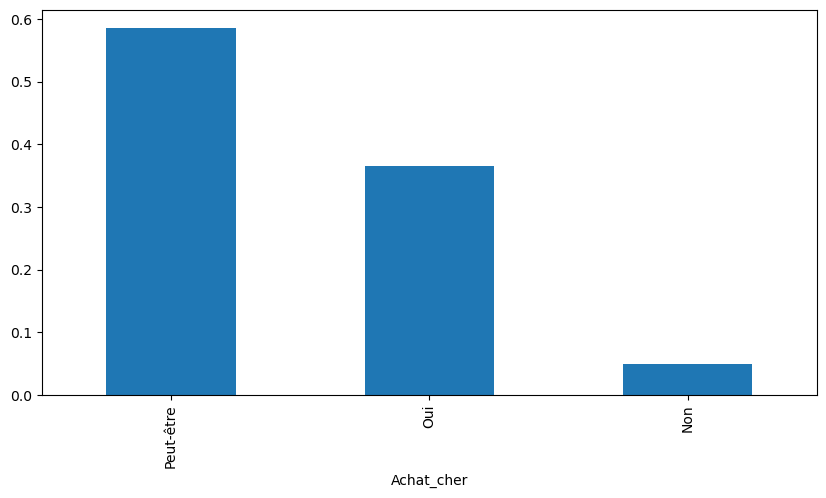

In [263]:
plt.figure(figsize=(10,5))
df['Achat_cher'].value_counts(normalize=True).plot(kind='bar');

In [264]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Emballages        123 non-null    object 
 1   Nbre_emballages   123 non-null    object 
 2   Objectif_embal    123 non-null    object 
 3   Type_emballage    123 non-null    object 
 4   Freq_obt_embal    123 non-null    object 
 5   Caract_embal_1    123 non-null    object 
 6   Caract_embal_2    123 non-null    object 
 7   Budget_emballage  123 non-null    float64
 8   Mode_approv       123 non-null    object 
 9   Type_mat_embal    123 non-null    object 
 10  Besoins_embal     123 non-null    object 
 11  Fenetre_embal     123 non-null    object 
 12  Contenance        123 non-null    object 
 13  Achats_plats      123 non-null    object 
 14  Prix_centaine     123 non-null    float64
 15  Achat_cher        123 non-null    object 
dtypes: float64(2), object(14)
memory usage: 15.5

In [265]:
df['Achat_cher'].unique()

array(['Non', 'Peut-être', 'Oui'], dtype=object)

In [266]:
df["Achat_cher"]=df['Achat_cher'].map({"Non": 0, "Peut-être":1,"Oui":2 })

In [267]:
df['Achat_cher'].dtype

dtype('int64')

In [268]:
#Sépration des colonnes numériques
numeric = df.select_dtypes(exclude='object')
objet = df.select_dtypes(include='object')

In [269]:
#Transformation de colonnes catégorielles
obj_dum = pd.get_dummies(objet, drop_first=True)

In [270]:
df_fin = pd.concat([numeric, obj_dum], axis=1)

In [271]:
df_fin

,Budget_emballage,Prix_centaine,Achat_cher,Nbre_emballages_Entre 1 et 30,Nbre_emballages_Entre 1-15,Nbre_emballages_Entre 15 et 30,Nbre_emballages_Entre 30 et 50,"Objectif_embal_Economie de couts, Experience Client","Objectif_embal_Economie de couts, Experience Client, Marketing Durable","Objectif_embal_Economie de couts, Innovation culinaire",...,Fenetre_embal_Oui,"Contenance_1100ML, Autres",Contenance_500ML,"Contenance_700ML, 800ML",Contenance_800ML,Contenance_850ML,"Contenance_850ML, 1100ML",Contenance_Autres,Achats_plats_Oui,Achats_plats_Peut être
0,5000.0,2.5,0,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
1,7000.0,5.0,1,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,10.0,5.0,1,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
3,15.0,7500.0,2,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,7000.0,2500.0,2,False,False,True,False,False,False,False,...,True,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,7000.0,2500.0,1,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
119,7000.0,2500.0,2,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
120,7000.0,2500.0,1,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
121,7000.0,2500.0,1,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False


In [272]:
# Séparation des explicatives et de l'expliquée
X = df_fin.drop('Achat_cher',axis=1)
y = df_fin['Achat_cher']

In [273]:
from sklearn.model_selection import train_test_split

In [274]:
#Sépration en données d'entrainement et en données test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [275]:
from sklearn.preprocessing import StandardScaler

In [276]:
scale = StandardScaler()

In [277]:
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled= scale.transform(X_test)

In [278]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

In [279]:
iso=IsolationForest(contamination=0.05)

In [280]:
iso.fit(df_fin)

IsolationForest(contamination=0.05)

In [281]:
y_pred=iso.predict(df_fin)

In [282]:
anomaly=np.where(y_pred==-1)
normal=np.where(y_pred==1)

Text(0.5, 1.0, 'Anomaly Detection Results')

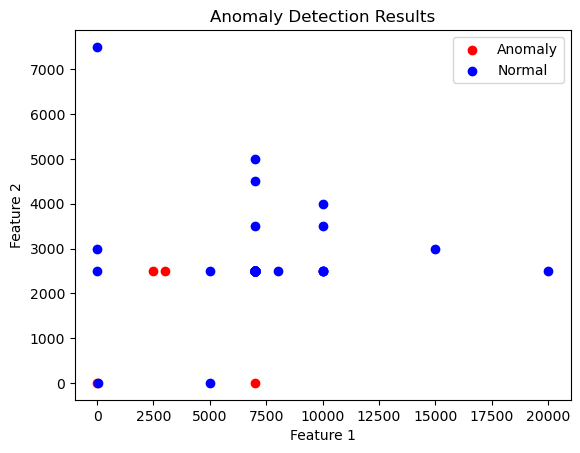

In [283]:
plt.scatter(df_fin.iloc[anomaly[0], 0], df_fin.iloc[anomaly[0], 1], c="Red", label="Anomaly")
plt.scatter(df_fin.iloc[normal[0], 0], df_fin.iloc[normal[0], 1], c="Blue", label="Normal")
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Anomaly Detection Results")

In [284]:
rl = LogisticRegression(class_weight='balanced')

In [285]:
rl.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [286]:
y_pred = rl.predict(X_test_scaled)

In [287]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [288]:
confusion_matrix(y_test, y_pred)

array([[1, 0, 0],
       [1, 6, 8],
       [0, 5, 4]])

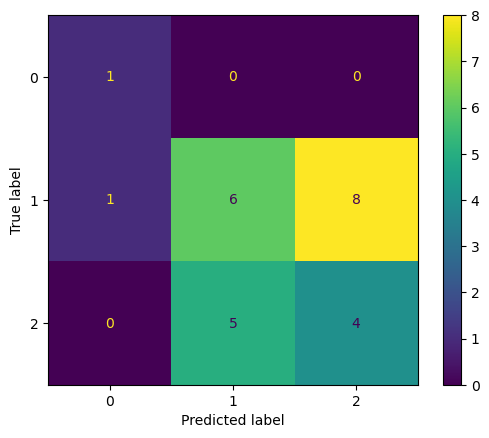

In [289]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

In [290]:
cible = ['Non', 'Peut-être','Oui']

In [291]:
print(classification_report(y_test, y_pred, target_names=cible))

              precision    recall  f1-score   support

         Non       0.50      1.00      0.67         1
   Peut-être       0.55      0.40      0.46        15
         Oui       0.33      0.44      0.38         9

    accuracy                           0.44        25
   macro avg       0.46      0.61      0.50        25
weighted avg       0.47      0.44      0.44        25



In [292]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [293]:
# Calcul des poids pour équilibrer les classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb=XGBClassifier()
xgb.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [294]:
y_pred=xgb.predict(X_test)

In [295]:
print(classification_report(y_test,y_pred,target_names=cible))

              precision    recall  f1-score   support

         Non       0.50      1.00      0.67         1
   Peut-être       0.64      0.47      0.54        15
         Oui       0.42      0.56      0.48         9

    accuracy                           0.52        25
   macro avg       0.52      0.67      0.56        25
weighted avg       0.55      0.52      0.52        25



In [296]:
from sklearn.ensemble import RandomForestClassifier

In [297]:
rf=RandomForestClassifier(n_estimators=100,max_depth=5,class_weight='balanced',random_state=0)
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=0)

In [298]:
y_pred=rf.predict(X_test)

In [299]:
print(classification_report(y_test,y_pred,target_names=cible))

              precision    recall  f1-score   support

         Non       0.50      1.00      0.67         1
   Peut-être       0.67      0.53      0.59        15
         Oui       0.45      0.56      0.50         9

    accuracy                           0.56        25
   macro avg       0.54      0.70      0.59        25
weighted avg       0.58      0.56      0.56        25



# SKLEARN

In [329]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [330]:
df_lin=df_fin.copy()

In [331]:
df_lin

,Budget_emballage,Prix_centaine,Achat_cher,Nbre_emballages_Entre 1 et 30,Nbre_emballages_Entre 1-15,Nbre_emballages_Entre 15 et 30,Nbre_emballages_Entre 30 et 50,"Objectif_embal_Economie de couts, Experience Client","Objectif_embal_Economie de couts, Experience Client, Marketing Durable","Objectif_embal_Economie de couts, Innovation culinaire",...,Fenetre_embal_Oui,"Contenance_1100ML, Autres",Contenance_500ML,"Contenance_700ML, 800ML",Contenance_800ML,Contenance_850ML,"Contenance_850ML, 1100ML",Contenance_Autres,Achats_plats_Oui,Achats_plats_Peut être
0,5000.0,2.5,0,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
1,7000.0,5.0,1,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,10.0,5.0,1,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
3,15.0,7500.0,2,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,7000.0,2500.0,2,False,False,True,False,False,False,False,...,True,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,7000.0,2500.0,1,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
119,7000.0,2500.0,2,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
120,7000.0,2500.0,1,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
121,7000.0,2500.0,1,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False


In [332]:

X=df_lin.drop("Budget_emballage", axis=1)
y=df_lin["Budget_emballage"]

In [333]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [334]:

scale_reg = StandardScaler()
X_train_scaled = scale_reg.fit_transform(X_train)
X_test_scaled = scale_reg.transform(X_test)

In [335]:
model=LinearRegression()


In [336]:
model.fit(X_train_scaled,y_train)

LinearRegression()

In [337]:
y_pred=model.predict(X_test_scaled)

In [338]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [339]:
mae=mean_absolute_error(y_test,y_pred)
mae

2623.7657230891764

In [340]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(5405.77489956052)

In [341]:
r2_score(y_test,y_pred)

-2.1916890505657416

In [342]:
from sklearn.ensemble import RandomForestRegressor

In [343]:
rf_reg=RandomForestRegressor()
rf_reg.fit(X_train, y_train)

RandomForestRegressor()

In [344]:
y_pred = rf_reg.predict(X_test)

In [345]:
r2_score(y_test, y_pred)

0.27989084865325886

In [346]:
from sklearn.svm import SVR

In [347]:
svm=SVR()
svm.fit(X_train_scaled,y_train)

SVR()

In [348]:
y_pred_svm=svm.predict(X_test_scaled)

In [349]:
r2_score(y_test,y_pred_svm)

-0.008614636167889822

In [350]:
from xgboost import XGBRegressor

In [351]:
xg_red=XGBRegressor()
xg_red.fit(X_train,y_train)
y_pred_xg=xg_red.predict(X_test)


In [352]:
r2_score(y_test,y_pred_xg)

0.26927317620979274

# Implémentation manuelle du Gradient Descent pour prédire Budget_emballage

In [ ]:
def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
  
    # Ajouter une colonne de 1 pour le biais (intercept)
    m = len(y)  # Nombre d'exemples
    X_b = np.c_[np.ones((m, 1)), X]  # Ajouter x0 = 1 pour chaque exemple
    
    # Initialiser les paramètres theta à zéro
    n_features = X_b.shape[1]
    theta = np.zeros(n_features)
    
    # Historique du coût
    cost_history = []
    
    # Descente de gradient
    for iteration in range(n_iterations):
        # Prédictions
        y_pred = X_b.dot(theta)
        
        # Erreur
        error = y_pred - y
        
        # Calcul du gradient
        gradient = (1/m) * X_b.T.dot(error)
        
        # Mise à jour des paramètres
        theta = theta - learning_rate * gradient
        
        # Calcul du coût (MSE)
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)
        
        # Afficher le coût toutes les 100 itérations
        if iteration % 100 == 0:
            print(f"Itération {iteration}: Coût = {cost:.4f}")
    
    return theta, cost_history

In [354]:
# Entraînement du modèle avec Gradient Descent
# Utiliser les données normalisées
theta_optimal, cost_history = gradient_descent(
    X_train_scaled, 
    y_train.values, 
    learning_rate=0.01, 
    n_iterations=1000
)

print(f"\n{'='*50}")
print(f"Paramètres optimaux trouvés:")
print(f"{'='*50}")
print(f"Intercept (theta[0]): {theta_optimal[0]:.4f}")
print(f"Nombre de coefficients: {len(theta_optimal)-1}")
print(f"Coût final: {cost_history[-1]:.4f}")

Itération 0: Coût = 25230871.5561
Itération 100: Coût = 3767206.1751
Itération 200: Coût = 826102.9613
Itération 300: Coût = 368361.5522
Itération 400: Coût = 267637.2979
Itération 500: Coût = 228549.6315
Itération 600: Coût = 205779.0652
Itération 700: Coût = 190200.6775
Itération 800: Coût = 178869.3453
Itération 900: Coût = 170357.0278

Paramètres optimaux trouvés:
Intercept (theta[0]): 6852.3062
Nombre de coefficients: 52
Coût final: 163875.9310


In [355]:
# Fonction pour faire des prédictions avec les theta optimaux
def predict(X, theta):
    """Faire des prédictions avec les paramètres theta"""
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]
    return X_b.dot(theta)

# Prédictions sur l'ensemble de test
y_pred_gd = predict(X_test_scaled, theta_optimal)

# Évaluation du modèle
mae_gd = mean_absolute_error(y_test, y_pred_gd)
rmse_gd = np.sqrt(mean_squared_error(y_test, y_pred_gd))
r2_gd = r2_score(y_test, y_pred_gd)

print(f"\n{'='*50}")
print(f"PERFORMANCES DU GRADIENT DESCENT MANUEL")
print(f"{'='*50}")
print(f"MAE (Mean Absolute Error): {mae_gd:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse_gd:.4f}")
print(f"R² Score: {r2_gd:.4f}")

# Comparaison avec sklearn
print(f"\n{'='*50}")
print(f"COMPARAISON AVEC SKLEARN LinearRegression")
print(f"{'='*50}")
print(f"R² Score Gradient Descent: {r2_gd:.4f}")
print(f"R² Score sklearn: {r2_score(y_test, model.predict(X_test_scaled)):.4f}")


PERFORMANCES DU GRADIENT DESCENT MANUEL
MAE (Mean Absolute Error): 2169.8826
RMSE (Root Mean Squared Error): 4709.9070
R² Score: -1.4229

COMPARAISON AVEC SKLEARN LinearRegression
R² Score Gradient Descent: -1.4229
R² Score sklearn: -2.1917


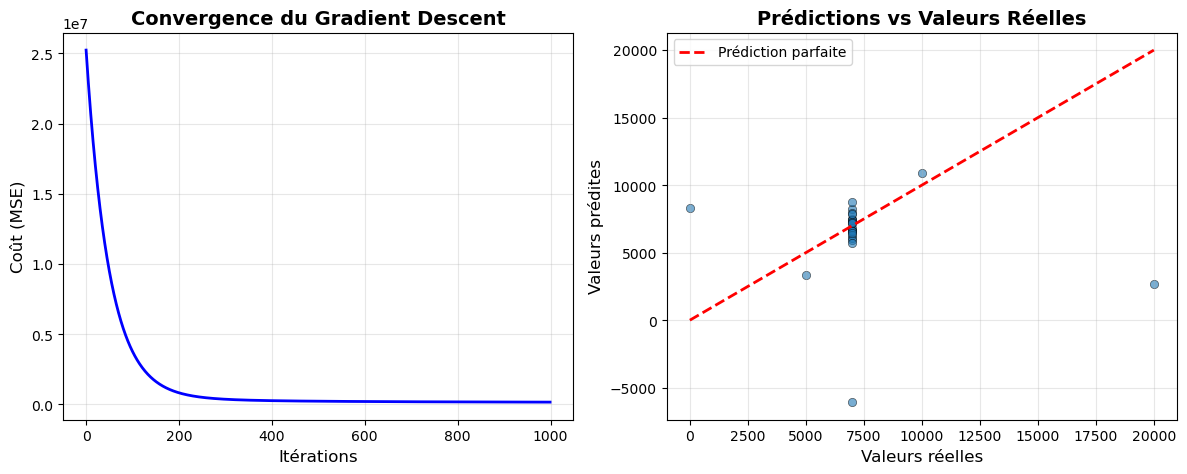

In [356]:
# Visualiser la convergence du coût
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cost_history, linewidth=2, color='blue')
plt.xlabel('Itérations', fontsize=12)
plt.ylabel('Coût (MSE)', fontsize=12)
plt.title('Convergence du Gradient Descent', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_gd, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Prédiction parfaite')
plt.xlabel('Valeurs réelles', fontsize=12)
plt.ylabel('Valeurs prédites', fontsize=12)
plt.title('Prédictions vs Valeurs Réelles', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()